> Benjamin Nikholas

> Data Science / JCSDOL-014

> Modul 3 - Tugas 8

> 4 Juli 2024
---
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, r2_score

In [5]:
df_diamonds = sns.load_dataset('diamonds')
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


Gunakan Carat, Depth, Table, x, y, z sebagai variabel independen

Gunakan Price sebagai variabel dependen

In [6]:
X = df_diamonds[['carat', 'depth', 'table', 'x', 'y', 'z']]
y = df_diamonds.price

Analisa korelasi antara independen dan dependen variabel

In [12]:
correlation = X.apply(lambda col: col.corr(y))
df_corr = pd.DataFrame(correlation.round(3), 
                       columns = ['correlation']).sort_values(by = 'correlation',
                                                              ascending = False)
df_corr

,correlation
carat,0.922
x,0.884
y,0.865
z,0.861
table,0.127
depth,-0.011


Interpretasi hasil korelasi

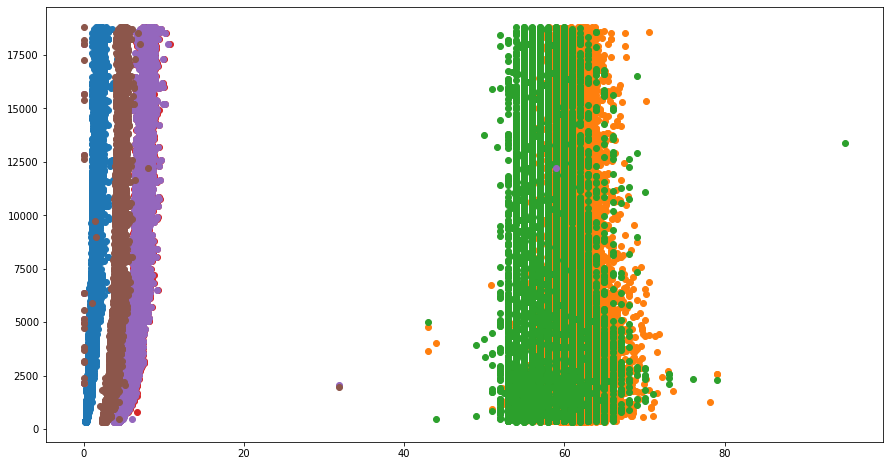

In [13]:
plt.figure(figsize = (15, 8))
for i in X:
    ind_values = df_diamonds[i]
    plt.scatter(ind_values,
                y)
plt.show()


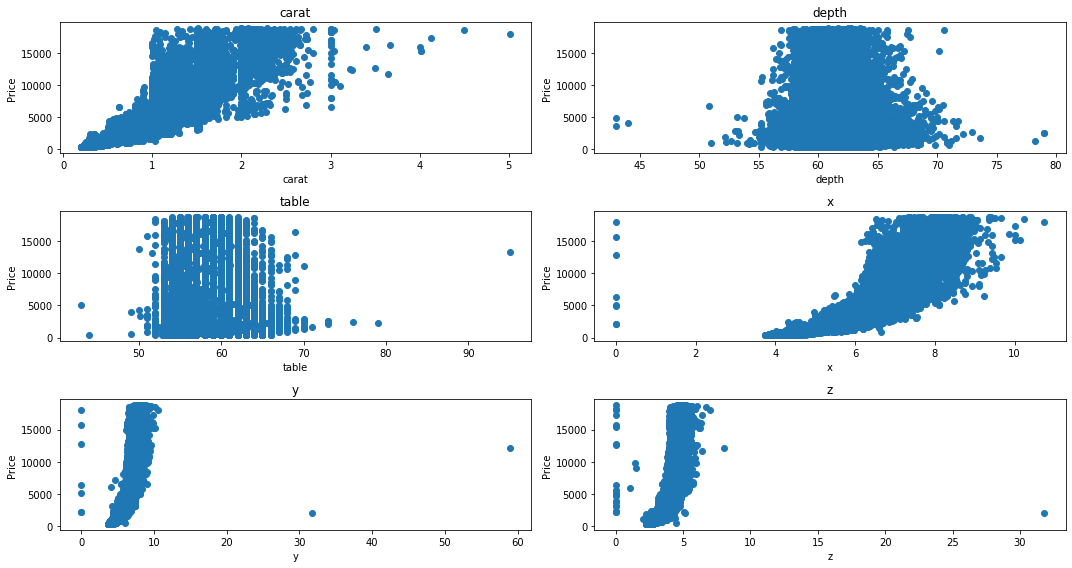

In [14]:
fig, ax = plt.subplots(3, 2,
                       figsize = (15, 8))

for i, var in enumerate(X.columns):
    row = i // 2
    col = i % 2
    # print(row, col)
    ax[row, col].scatter(df_diamonds[var], y)
    ax[row, col].set_title(var)
    ax[row, col].set_xlabel(var)
    ax[row, col].set_ylabel('Price')
plt.tight_layout()
plt.show()

Lakukan Multiple Linear Regression

Keluarkan hasi regresi tersebut (baik dari Intercept maupun Slopenya)

In [15]:
model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
slope = model.coef_[0]

print(f'Intercept: {intercept:.3f}')
print(f'Slope: {slope:.3f}')

Intercept: 20849.316
Slope: 10686.309


Interpretasikan hasilnya

In [19]:
y_pred = pd.DataFrame(model.predict(X))
display(y_pred)

,0
0,346.909718
1,-71.468765
2,126.368674
3,193.901639
4,53.549591
...,...
53935,3314.909673
53936,3135.402558
53937,2503.140469
53938,4175.515769


In [21]:
print(len(y), len(y_pred))

53940 53940


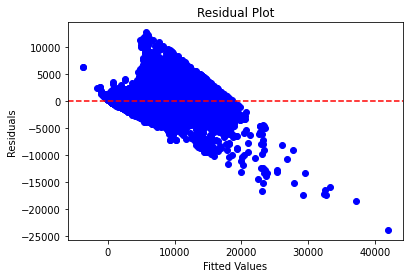

In [28]:
# Residual plot
residuals = pd.DataFrame(y - y_pred)
# display(residuals)

plt.scatter(y_pred, residuals, color='blue')
plt.axhline(y = 0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

Lakukan evaluasi terhadap hasil linreg tersebut

In [23]:
mse = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f'Mean Absolute Percentage Error (MAPE): {mse:.2f}')
print(f'R^2 Score: {r2:.2f}')

Mean Absolute Percentage Error (MAPE): 0.28
R^2 Score: 0.86


Buat analisa error